In [1]:
# Unsupervised learning

In [12]:
# Clustering

Original Dataset:
    Age  Annual_Income
0    20             20
1    21             22
2    22             24
3    23             25
4    24             27
5    25             28
6    26             30
7    27             32
8    35             55
9    36             58
10   37             60
11   38             62
12   39             65
13   40             67
14   41             70
15   42             72
16   50             90
17   51             92
18   52             95
19   53             98
20   54            100
21   55            105
22   56            108
23   57            110


C:\Users\saiki\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\saiki\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\saiki\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\saiki\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

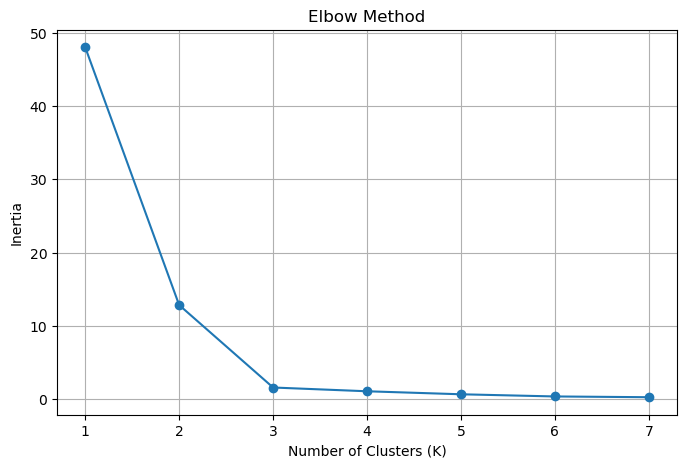

C:\Users\saiki\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(



Dataset with Cluster Labels:
    Age  Annual_Income  Cluster
0    20             20        2
1    21             22        2
2    22             24        2
3    23             25        2
4    24             27        2
5    25             28        2
6    26             30        2
7    27             32        2
8    35             55        0
9    36             58        0
10   37             60        0
11   38             62        0
12   39             65        0
13   40             67        0
14   41             70        0
15   42             72        0
16   50             90        1
17   51             92        1
18   52             95        1
19   53             98        1
20   54            100        1
21   55            105        1
22   56            108        1
23   57            110        1

Silhouette Score:
0.787

Cluster Centers:
[[-1.15648232e-17  1.63297048e-02]
 [ 1.20385853e+00  1.19615088e+00]
 [-1.20385853e+00 -1.21248058e+00]]


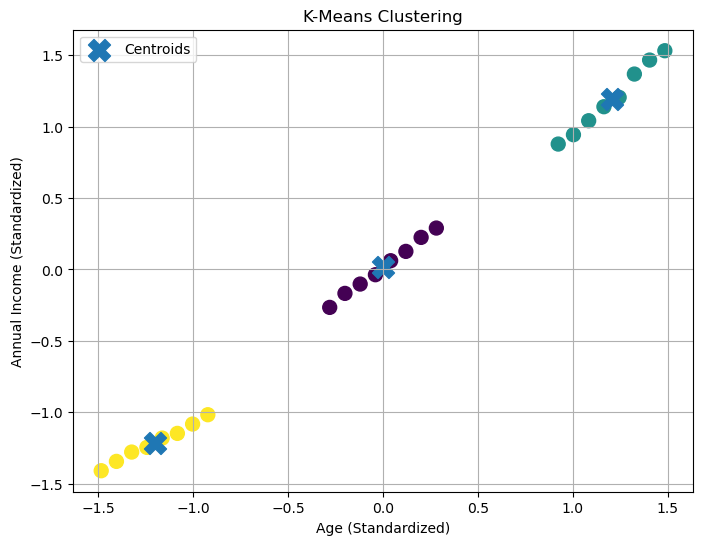

In [13]:
# ============================================
# K-MEANS CLUSTERING
# ============================================

import os
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --------------------------------------------
# STEP 1: CREATE DATASET
# --------------------------------------------

data = {
    "Age": [20, 21, 22, 23, 24, 25, 26, 27, 35, 36,
            37, 38, 39, 40, 41, 42, 50, 51, 52, 53,
            54, 55, 56, 57],

    "Annual_Income": [20, 22, 24, 25, 27, 28, 30, 32,
                      55, 58, 60, 62, 65, 67, 70, 72,
                      90, 92, 95, 98, 100, 105, 108, 110]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# --------------------------------------------
# STEP 2: SELECT FEATURES
# --------------------------------------------

X = df[["Age", "Annual_Income"]]

# --------------------------------------------
# STEP 3: STANDARDIZATION
# --------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# STEP 4: ELBOW METHOD
# --------------------------------------------

inertia = []

for k in range(1, 8):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 8), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid()
plt.show()

# --------------------------------------------
# STEP 5: APPLY K-MEANS
# --------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# --------------------------------------------
# STEP 6: PRINT CLUSTER LABELS
# --------------------------------------------

print("\nDataset with Cluster Labels:")
print(df)

# --------------------------------------------
# STEP 7: SILHOUETTE SCORE
# --------------------------------------------

sil_score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:")
print(round(sil_score, 3))

# --------------------------------------------
# STEP 8: CLUSTER CENTERS
# --------------------------------------------

centers = kmeans.cluster_centers_

print("\nCluster Centers:")
print(centers)

# --------------------------------------------
# STEP 9: VISUALIZE CLUSTERS
# --------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=100
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker="X",
    s=250,
    label="Centroids"
)

plt.xlabel("Age (Standardized)")
plt.ylabel("Annual Income (Standardized)")
plt.title("K-Means Clustering")
plt.legend()
plt.grid()

plt.show()

Original Dataset:
    Age  Income
0    20      20
1    21      21
2    22      23
3    23      24
4    24      25
5    25      27
6    35      50
7    36      52
8    37      54
9    38      55
10   39      57
11   40      59
12   50      80
13   51      82
14   52      84
15   53      86
16   54      88
17   55      90
18   80     150
19   82     160

Dataset with DBSCAN Cluster Labels:
    Age  Income  Cluster
0    20      20        0
1    21      21        0
2    22      23        0
3    23      24        0
4    24      25        0
5    25      27        0
6    35      50        1
7    36      52        1
8    37      54        1
9    38      55        1
10   39      57        1
11   40      59        1
12   50      80        2
13   51      82        2
14   52      84        2
15   53      86        2
16   54      88        2
17   55      90        2
18   80     150       -1
19   82     160       -1

Number of Clusters:
3

Number of Noise Points:
2

Silhouette Score:
0.849


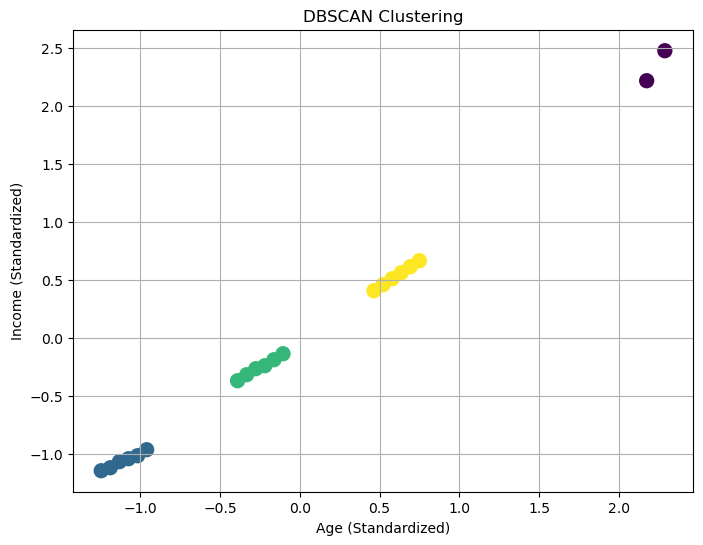

In [7]:
# ============================================
# DBSCAN CLUSTERING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# --------------------------------------------
# STEP 1: CREATE DATASET
# --------------------------------------------

data = {
    "Age": [
        20, 21, 22, 23, 24, 25,
        35, 36, 37, 38, 39, 40,
        50, 51, 52, 53, 54, 55,
        80, 82
    ],

    "Income": [
        20, 21, 23, 24, 25, 27,
        50, 52, 54, 55, 57, 59,
        80, 82, 84, 86, 88, 90,
        150, 160
    ]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# --------------------------------------------
# STEP 2: SELECT FEATURES
# --------------------------------------------

X = df[["Age", "Income"]]

# --------------------------------------------
# STEP 3: STANDARDIZATION
# --------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# STEP 4: APPLY DBSCAN
# --------------------------------------------

dbscan = DBSCAN(
    eps=0.45,
    min_samples=3
)

clusters = dbscan.fit_predict(X_scaled)

df["Cluster"] = clusters

# --------------------------------------------
# STEP 5: DISPLAY RESULTS
# --------------------------------------------

print("\nDataset with DBSCAN Cluster Labels:")
print(df)

# --------------------------------------------
# STEP 6: FIND NUMBER OF CLUSTERS
# --------------------------------------------

unique_clusters = set(clusters)

number_of_clusters = len(
    unique_clusters - {-1}
)

print("\nNumber of Clusters:")
print(number_of_clusters)

# --------------------------------------------
# STEP 7: FIND NOISE POINTS
# --------------------------------------------

noise_points = list(clusters).count(-1)

print("\nNumber of Noise Points:")
print(noise_points)

# --------------------------------------------
# STEP 8: SILHOUETTE SCORE
# --------------------------------------------

if number_of_clusters > 1:

    non_noise = clusters != -1

    score = silhouette_score(
        X_scaled[non_noise],
        clusters[non_noise]
    )

    print("\nSilhouette Score:")
    print(round(score, 3))

else:
    print("\nSilhouette Score cannot be calculated.")

# --------------------------------------------
# STEP 9: VISUALIZATION
# --------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=100
)

plt.xlabel("Age (Standardized)")
plt.ylabel("Income (Standardized)")
plt.title("DBSCAN Clustering")
plt.grid()

plt.show()

Original Dataset:
    Age  Income
0    20      20
1    21      22
2    22      24
3    23      25
4    24      27
5    35      50
6    36      52
7    37      54
8    38      55
9    39      57
10   50      80
11   51      82
12   52      84
13   53      86
14   54      88


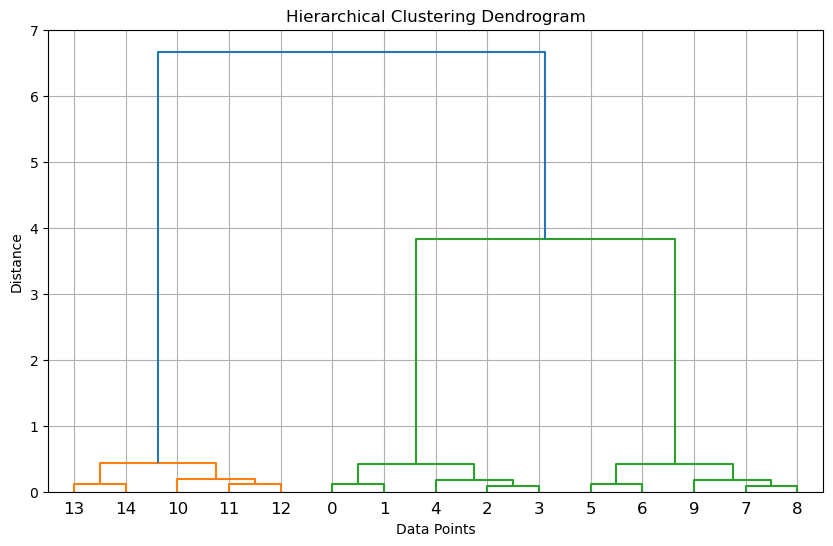


Dataset with Cluster Labels:
    Age  Income  Cluster
0    20      20        2
1    21      22        2
2    22      24        2
3    23      25        2
4    24      27        2
5    35      50        1
6    36      52        1
7    37      54        1
8    38      55        1
9    39      57        1
10   50      80        0
11   51      82        0
12   52      84        0
13   53      86        0
14   54      88        0

Silhouette Score:
0.869


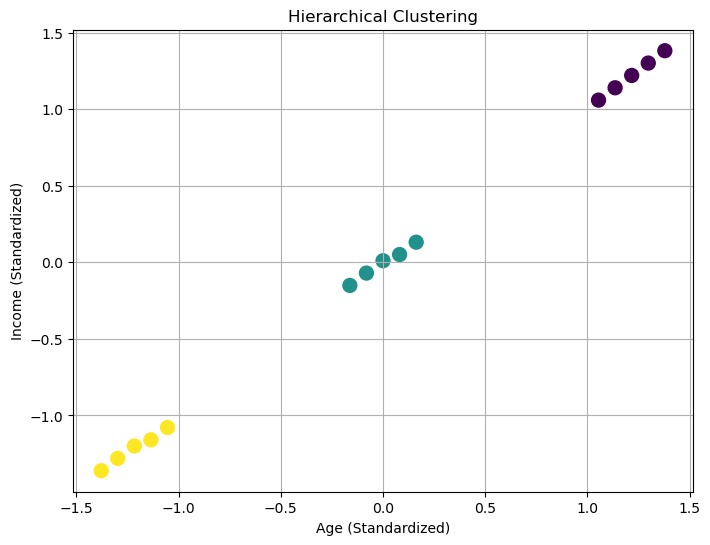

In [8]:
# ============================================
# HIERARCHICAL CLUSTERING
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

# --------------------------------------------
# STEP 1: CREATE DATASET
# --------------------------------------------

data = {
    "Age": [
        20, 21, 22, 23, 24,
        35, 36, 37, 38, 39,
        50, 51, 52, 53, 54
    ],

    "Income": [
        20, 22, 24, 25, 27,
        50, 52, 54, 55, 57,
        80, 82, 84, 86, 88
    ]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# --------------------------------------------
# STEP 2: SELECT FEATURES
# --------------------------------------------

X = df[["Age", "Income"]]

# --------------------------------------------
# STEP 3: STANDARDIZATION
# --------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# STEP 4: CREATE DENDROGRAM
# --------------------------------------------

linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(10, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.grid()
plt.show()

# --------------------------------------------
# STEP 5: APPLY AGGLOMERATIVE CLUSTERING
# --------------------------------------------

hc = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

clusters = hc.fit_predict(X_scaled)

df["Cluster"] = clusters

# --------------------------------------------
# STEP 6: DISPLAY CLUSTERS
# --------------------------------------------

print("\nDataset with Cluster Labels:")
print(df)

# --------------------------------------------
# STEP 7: SILHOUETTE SCORE
# --------------------------------------------

score = silhouette_score(
    X_scaled,
    clusters
)

print("\nSilhouette Score:")
print(round(score, 3))

# --------------------------------------------
# STEP 8: VISUALIZATION
# --------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters,
    s=100
)

plt.xlabel("Age (Standardized)")
plt.ylabel("Income (Standardized)")
plt.title("Hierarchical Clustering")
plt.grid()

plt.show()

In [9]:
## Dimensionality Reduction

Original Dataset:
   Math  Science  English  Computer
0    80       78       75        85
1    85       82       80        88
2    90       91       88        95
3    70       72       70        75
4    75       76       74        80
5    95       94       90        98
6    60       62       65        68
7    65       67       68        72
8    88       86       84        90
9    92       90       89        94

PCA Transformed Data:
        PC1       PC2
0 -0.251602 -0.329321
1  0.602486 -0.174954
2  2.078092  0.132567
3 -1.779673 -0.021627
4 -0.880730 -0.033178
5  2.711634  0.008745
6 -3.351900  0.147475
7 -2.511754  0.089391
8  1.261056  0.010974
9  2.122392  0.169928

Explained Variance Ratio:
PC1: 99.20%
PC2: 0.54%

Total Explained Variance:
99.74%


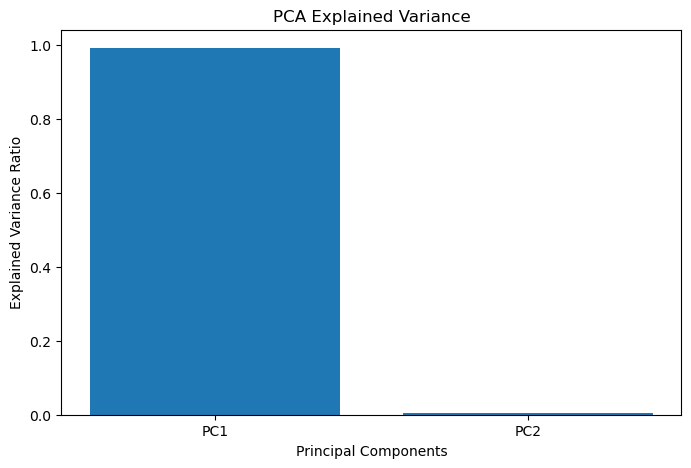

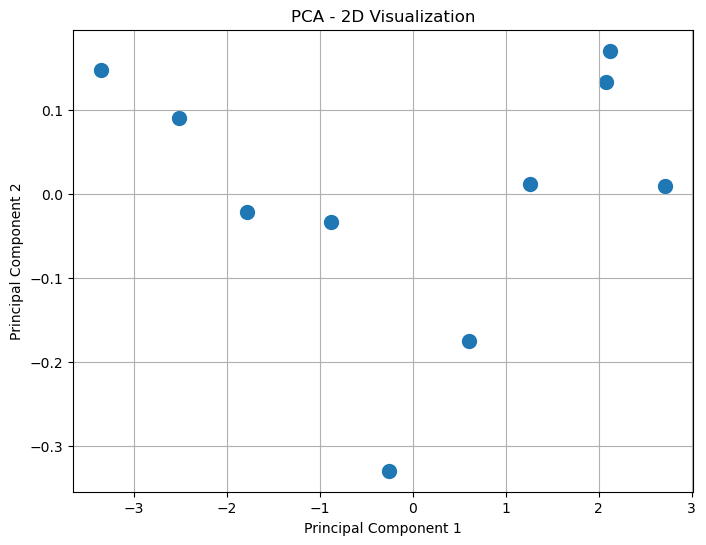

In [10]:
# ============================================
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# --------------------------------------------
# STEP 1: CREATE DATASET
# --------------------------------------------

data = {
    "Math": [80, 85, 90, 70, 75, 95, 60, 65, 88, 92],
    "Science": [78, 82, 91, 72, 76, 94, 62, 67, 86, 90],
    "English": [75, 80, 88, 70, 74, 90, 65, 68, 84, 89],
    "Computer": [85, 88, 95, 75, 80, 98, 68, 72, 90, 94]
}

df = pd.DataFrame(data)

print("Original Dataset:")
print(df)

# --------------------------------------------
# STEP 2: SELECT FEATURES
# --------------------------------------------

X = df[
    ["Math", "Science", "English", "Computer"]
]

# --------------------------------------------
# STEP 3: STANDARDIZATION
# --------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# STEP 4: APPLY PCA
# --------------------------------------------

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)

# --------------------------------------------
# STEP 5: CREATE PCA DATAFRAME
# --------------------------------------------

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print("\nPCA Transformed Data:")
print(pca_df)

# --------------------------------------------
# STEP 6: EXPLAINED VARIANCE
# --------------------------------------------

explained_variance = pca.explained_variance_ratio_

print("\nExplained Variance Ratio:")

for i, value in enumerate(
    explained_variance
):

    print(
        f"PC{i+1}: {value:.2%}"
    )

# --------------------------------------------
# STEP 7: TOTAL EXPLAINED VARIANCE
# --------------------------------------------

total_variance = sum(
    explained_variance
)

print("\nTotal Explained Variance:")
print(f"{total_variance:.2%}")

# --------------------------------------------
# STEP 8: EXPLAINED VARIANCE GRAPH
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")

plt.show()

# --------------------------------------------
# STEP 9: PCA SCATTER PLOT
# --------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=100
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA - 2D Visualization")

plt.grid()
plt.show()

Original Dataset:
    Math  Science  English      Class
0     90       92       88  Excellent
1     88       86       85  Excellent
2     92       90       90  Excellent
3     85       88       84  Excellent
4     87       89       86  Excellent
5     65       67       64    Average
6     68       70       68    Average
7     70       72       70    Average
8     62       64       60    Average
9     66       65       65    Average
10    45       46       44       Poor
11    48       50       47       Poor
12    50       48       49       Poor
13    42       44       41       Poor
14    47       45       46       Poor

LDA Transformed Data:
          LD1       LD2      Class
0   11.628251  0.287238  Excellent
1   10.004688  2.111294  Excellent
2   10.687256  0.774109  Excellent
3    8.784002 -0.972627  Excellent
4    9.212648 -0.886034  Excellent
5   -0.524462 -0.370878    Average
6   -0.284490 -1.684647    Average
7    0.600701 -1.731479    Average
8   -0.764434  0.942892    Average
9

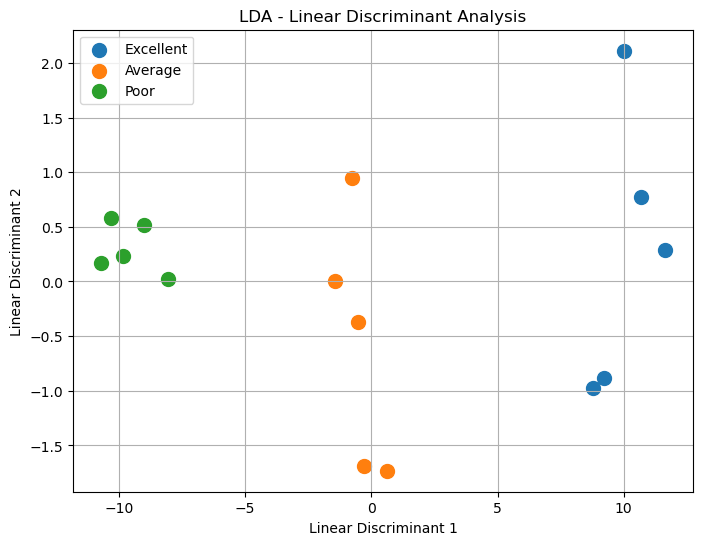

In [11]:
# ============================================
# LINEAR DISCRIMINANT ANALYSIS (LDA)
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --------------------------------------------
# STEP 1: CREATE DATASET
# --------------------------------------------

data = {
    "Math": [
        90, 88, 92, 85, 87,
        65, 68, 70, 62, 66,
        45, 48, 50, 42, 47
    ],

    "Science": [
        92, 86, 90, 88, 89,
        67, 70, 72, 64, 65,
        46, 50, 48, 44, 45
    ],

    "English": [
        88, 85, 90, 84, 86,
        64, 68, 70, 60, 65,
        44, 47, 49, 41, 46
    ]
}

df = pd.DataFrame(data)

# --------------------------------------------
# STEP 2: CREATE TARGET
# --------------------------------------------

df["Class"] = [
    "Excellent", "Excellent", "Excellent",
    "Excellent", "Excellent",

    "Average", "Average", "Average",
    "Average", "Average",

    "Poor", "Poor", "Poor",
    "Poor", "Poor"
]

print("Original Dataset:")
print(df)

# --------------------------------------------
# STEP 3: SELECT FEATURES AND TARGET
# --------------------------------------------

X = df[
    ["Math", "Science", "English"]
]

y = df["Class"]

# --------------------------------------------
# STEP 4: STANDARDIZATION
# --------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# STEP 5: APPLY LDA
# --------------------------------------------

lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

# --------------------------------------------
# STEP 6: CREATE TRANSFORMED DATAFRAME
# --------------------------------------------

lda_df = pd.DataFrame(
    X_lda,
    columns=["LD1", "LD2"]
)

lda_df["Class"] = y.values

print("\nLDA Transformed Data:")
print(lda_df)

# --------------------------------------------
# STEP 7: EXPLAINED VARIANCE
# --------------------------------------------

print("\nLDA Explained Variance Ratio:")

for i, value in enumerate(
    lda.explained_variance_ratio_
):

    print(
        f"LD{i+1}: {value:.2%}"
    )

# --------------------------------------------
# STEP 8: TOTAL EXPLAINED VARIANCE
# --------------------------------------------

total_variance = sum(
    lda.explained_variance_ratio_
)

print("\nTotal Explained Variance:")
print(f"{total_variance:.2%}")

# --------------------------------------------
# STEP 9: VISUALIZATION
# --------------------------------------------

plt.figure(figsize=(8, 6))

classes = y.unique()

for class_name in classes:

    subset = lda_df[
        lda_df["Class"] == class_name
    ]

    plt.scatter(
        subset["LD1"],
        subset["LD2"],
        s=100,
        label=class_name
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")

plt.title(
    "LDA - Linear Discriminant Analysis"
)

plt.legend()
plt.grid()

plt.show()